<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH04/CH04_NB01_Cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

#Rearchitecting LLMs
## Structural techniques for efficient models


### Chapter 4: Depth Pruning: Building Smaller and Faster Models

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4

Models:
* Qwen3-0.6B
_____

In this notebook we explore how to evaluate the contribution of different transformer blocks to the LLM's objective using a dataset.

To do this, we use cosine similarity between the input and the output of the transformer block. The lower the similarity, the greater the modification that block has introduced to the data.

Blocks with higher similarity between input and output will be the candidates to be removed from the model.

# Setting up notebook

In [1]:
!pip install -q \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "sentence-transformers==5.1.0" \
      "datasets==3.5.0" \
      "optipfair==0.1.5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.4/483.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.1 MB/s eta 0:00:00

In [2]:
import torch, random
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM
import os
import json
from optipfair import analyze_layer_importance, prune_model_depth, prune_model

In [3]:
def set_reproducibility(seed=42):
    # 1. Seed for Python and basic libraries
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. Seed for PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU

    # 3. Configure cuDNN to be deterministic
    # Note: This may slow down training slightly
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 4. Seed for Transformers (Hugging Face)
    set_seed(seed)

    print(f"✅ Seed {seed} stablished.")

set_reproducibility(42)

✅ Seed 42 stablished.


In [4]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [5]:
def evaluate_metrics(model, dataloader, device='cuda'):
    model.eval()
    model.to(device)

    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Create labels, ignoring padding (-100 = ignore_index)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            # Forward pass
            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            # Only real tokens (no padding)
            num_real_tokens = attention_mask.sum().item()

            total_loss += outputs.loss.item() * num_real_tokens
            total_tokens += num_real_tokens

    # metrics
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)

    return {
        'loss': avg_loss,
        'perplexity': perplexity
    }

## Load Model

In [6]:
MODEL_NAME = 'Qwen/Qwen3-0.6B'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

## Load Datasets

In [7]:
RECOVERY_SAMPLES = 1000
BATCH_SIZE = 4
MAX_LENGTH = 512

We’re going to use two different datasets to visualize how some layers are more important than others depending on the data being used.

* **Wikitext**: Contains highly complex text. To process this kind of text, the model needs to rely on its deeper layers to understand context, semantic relations, and complex grammatical structures.
* **SMS Spam**: A completely different dataset, made up of short sentences with simple and direct language. It doesn’t require deep semantic understanding.


In [8]:
datawiki = load_dataset('wikitext', 'wikitext-2-raw-v1', split=f'train[:{RECOVERY_SAMPLES}]')

datasms = load_dataset('sms_spam', split=f'train[:{RECOVERY_SAMPLES}]')

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

In [9]:
def prepare_dataset(dataset, text_field='text'):
    def tokenize_function(examples):
        if text_field in examples:
            texts = examples[text_field]
        elif 'sms' in examples:
            texts = examples['sms']
        elif 'text' in examples:
            texts = examples['text']
        else:
            texts = examples[list(examples.keys())[0]]

        return tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors=None  # Listas, no tensores — evita el torch_formatter
        )

    tokenized = dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)

    # Convertimos a tensores manualmente en el collate_fn,
    # evitando el formatter de datasets que tiene el bug de VideoReader
    def collate_fn(examples):
        input_ids = torch.tensor([e['input_ids'] for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e['attention_mask'] for e in examples], dtype=torch.long)
        return {'input_ids': input_ids, 'attention_mask': attention_mask}

    return DataLoader(tokenized, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [10]:
# Crear dataloaders
dataloaderwiki = prepare_dataset(datawiki)  # WikiText (largo)
dataloadersms = prepare_dataset(datasms)  # SMS (corto)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

# 4.2 Static block selection
In this section, we're going to explore different strategies to make this decision. We'll start with the most direct and simple approaches, known as static or "data-free"



## 4.2.1 Removing first, last, middle blocks
Static approaches are those based on analyzing the structure and initial weights of the model.

In [11]:
# Based in position.
from copy import deepcopy

num_to_remove = 4
num_layers = len(model.model.layers)  # 32

# Calculate mid point
mid_point = num_layers // 2

# Calculate start and end
start_remove_index = mid_point - (num_to_remove // 2)
end_remove_index = start_remove_index + num_to_remove

print(f"Number of layers: {num_layers}")
print(f"Layers to remove {num_to_remove}.")
print(f"removing from {start_remove_index} to {end_remove_index - 1}")

pruned_model = deepcopy(model)

layers_before = pruned_model.model.layers[:start_remove_index]
layers_after = pruned_model.model.layers[end_remove_index:]

# Asign layers to the model.
pruned_model.model.layers = layers_before + layers_after

print(f"Layers in pruned model: {len(pruned_model.model.layers)}")
print(f"Removed layers: {num_layers - len(pruned_model.model.layers)}")

Number of layers: 28
Layers to remove 4.
removing from 12 to 15
Layers in pruned model: 24
Removed layers: 4


In [12]:
metrics_pruned_static_sms = evaluate_metrics(pruned_model, dataloadersms)

Evaluating: 100%|██████████| 250/250 [00:52<00:00,  4.75it/s]


In [13]:
metrics_pruned_static_sms

{'loss': 5.7033060500711885, 'perplexity': np.float64(299.85710666614773)}

loss': 8.10753679829326, 'perplexity': np.float64(3319.3916205392643

In [14]:
# Based in weigths
def calculate_layer_magnitude(layer):
    total_magnitude = 0
    for param in layer.parameters():
        total_magnitude += torch.norm(param).item()
    return total_magnitude

# Calculate magnitude for each layer
layer_magnitudes = []
for i, layer in enumerate(model.model.layers):
    magnitude = calculate_layer_magnitude(layer)
    layer_magnitudes.append((i, magnitude))

# Remove layers with lower magnitude
layer_magnitudes.sort(key=lambda x: x[1])  # Sort by magnitude
layers_to_remove = [idx for idx, _ in layer_magnitudes[:4]]  # Remove layers with lower

print(layers_to_remove)

[8, 2, 7, 6]


# 4.3 Data-Driven block selection

To decide which layers to remove, we measure their contribution using cosine similarity. We chose this metric because it’s perfect for this task: it measures the change in semantic direction between the input and output vectors of a layer, ignoring their magnitude.

This gives us a normalized score that we convert into an importance score (1 - similarity).

A score close to zero identifies a “passive” layer that barely alters the information, making it an ideal candidate for removal.


## 4.3.1 Using PyTorch hooks







We define a simple function to use as a hook that shows the shape of the input tensor and the output tensor.

In [15]:
def print_shape_hook(module, input, output):
    """
    Hook function that prints tensor shapes
    module: the layer where the hook is attached
    input: tuple of input tensors to the layer
    output: the output tensor from the layer
    """
    # Input is a tuple, we take the first element (the hidden states)
    print(f"Module class: {module.__class__.__name__}")
    print(f"Module id: {id(module)}")
    input_tensor = input[0]
    print(f"Input shape:  {input_tensor.shape}")
    print(f"Output shape: {output.shape}")

We register the hook in the first transformer block.Retry

In [16]:
# Register the hook on the first transformer block
first_layer = model.model.layers[0]
hook_handle = first_layer.register_forward_hook(print_shape_hook)

We run a forward with the model and get the hook result that Pytorch executes automatically.

In [17]:
# Test with a simple input
test_text = "He sat on the river bank to fish"
inputs = tokenizer(test_text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

Module class: Qwen3DecoderLayer
Module id: 136813438098160
Input shape:  torch.Size([1, 8, 1024])
Output shape: torch.Size([1, 8, 1024])


We remove the hooks.

In [18]:
# Remove the hook when done
hook_handle.remove()

If we run the forward again, the hook no longer executesRetry

In [19]:
with torch.no_grad():
    outputs = model(**inputs)

## 4.3.2 Understanding cosine similarity.

In [20]:
from sentence_transformers import SentenceTransformer
import torch
import torch.nn.functional as F

# Load standard sentence embedding model
modelst = SentenceTransformer('all-MiniLM-L6-v2')

# Three example sentences: two semantically similar, one different
sentences = [
    "The cat naps on the sofa.",
    "The feline is peacefully slumbering on the couch.",
    "The bus stops at the corner."
]

embeddings = modelst.encode(sentences, convert_to_tensor=True)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by {embeddings.shape[1]} dimensions\n")

# Calculate cosine similarity matrix using PyTorch
# We need to compute all pairs, so we use matrix multiplication
# First normalize embeddings
embeddings_normalized = F.normalize(embeddings, p=2, dim=1)

# Compute similarity matrix (cosine = dot product of normalized vectors)
similarity_matrix = torch.mm(embeddings_normalized, embeddings_normalized.T)

print("Cosine Similarity Matrix:")
print(similarity_matrix)
print("\nInterpretation:")
print(f"Sentence 1 vs Sentence 2: {similarity_matrix[0][1]:.4f} (semantically similar)")
print(f"Sentence 1 vs Sentence 3: {similarity_matrix[0][2]:.4f} (different topics)")
print("\nNote: Values close to 1.0 indicate high similarity")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: torch.Size([3, 384])
Each sentence is represented by 384 dimensions

Cosine Similarity Matrix:
tensor([[1.0000, 0.6106, 0.0563],
        [0.6106, 1.0000, 0.0504],
        [0.0563, 0.0504, 1.0000]], device='cuda:0')

Interpretation:
Sentence 1 vs Sentence 2: 0.6106 (semantically similar)
Sentence 1 vs Sentence 3: 0.0563 (different topics)

Note: Values close to 1.0 indicate high similarity


## 4.3.3 Analyzing block contributions across different datasets


To capture the input and output of the layers we use PyTorch hooks, which let us study/spy on the model’s behavior.


In [21]:
def setup_layer_hooks(model):
    """
    Register hooks to capture input/output of each transformer layer
    Returns: hooks list and storage dictionaries
    """
    num_layers = len(model.model.layers)
    layer_inputs = {}
    layer_outputs = {}
    hooks = []

    def create_hook(layer_idx): #B
        def hook(module, input, output): #C
            input_tensor = input[0] if isinstance(input, tuple) else input
            layer_inputs[layer_idx] = input_tensor.detach() #D

            output_tensor = output[0] if isinstance(output, tuple) else output
            layer_outputs[layer_idx] = output_tensor.detach() #D
        return hook

    # Register hooks for each layer
    for i, layer in enumerate(model.model.layers):
        hooks.append(
            layer.register_forward_hook(create_hook(i))
            )

    return hooks, layer_inputs, layer_outputs, num_layers

### Calculate Cosine Similarity

In [22]:
def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    """
    Computes the importance score of an attention sublayer for a single batch,
    properly masking out padding tokens to prevent artificial similarity inflation.
    """
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    # Calculate cosine similarity along the hidden state dimension (dim=-1)
    # Tensors shape: [batch_size, seq_len, hidden_size] -> similarities shape: [batch_size, seq_len]
    similarities = F.cosine_similarity(input_tensor, output_tensor, dim=-1)

    # Ensure the attention mask matches the dimensions and device of the similarities tensor
    attention_mask = attention_mask.to(similarities.device)

    # Zero out similarity scores belonging to padding tokens (where mask is 0)
    valid_similarities = similarities * attention_mask

    # Count only the authentic text tokens present in the current batch
    num_valid_tokens = attention_mask.sum()

    if num_valid_tokens == 0:
        if is_first_batch:
            print(f"Warning: layer {layer_idx} contained only padding tokens in this batch.")
        return 0.0

    # Compute the average similarity strictly across non-padding tokens
    mean_similarity = valid_similarities.sum() / num_valid_tokens

    # Guard against non-finite metrics (NaN/Inf) that corrupt the aggregate results
    if not torch.isfinite(mean_similarity):
         if is_first_batch:
            print(f"Warning: layer {layer_idx} generated non-finite similarity values.")
         return 0.0

    # Importance metric calculation based on Equation 1: S = 1 - CosineSim(X, Y)
    return 1.0 - mean_similarity.item()

We aggregate the results

This function takes the importance scores collected from all data batches for each layer. Then, it computes the average of these scores to get a single final consolidated importance score for each layer of the model.

In [23]:
def calculate_layer_importance_cosine(model, dataloader, device):
    """
    Calculate layer importance using cosine similarity between input/output representations

    Args:
        model: Transformer model
        dataloader: DataLoader with tokenized text data
        device: torch device (cuda/cpu)

    Returns:
        dict: Layer importance scores {layer_idx: importance_score}
    """
    # Setup hooks and storage
    hooks, layer_inputs, layer_outputs, num_layers = setup_layer_hooks(model)
    layer_importance_scores = {i: [] for i in range(num_layers)}

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader,
                                               desc="Processing batches")):
            inputs = {k: v.to(device) for k, v in batch.items()}

            # Forward pass to trigger hooks
            model(**inputs)

            # Calculate importance for each layer
            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Layer {layer_idx} Hook failed.")

                block_importance = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    inputs['attention_mask'],
                    layer_idx,
                    is_first_batch=(batch_idx == 0))

                layer_importance_scores[layer_idx].append(block_importance)

            # Clear storage for next batch
            layer_inputs.clear()
            layer_outputs.clear()

    # Cleanup hooks
    [hook.remove() for hook in hooks]

    # Aggregate final scores
    final_scores = {}

    for layer_idx, scores in layer_importance_scores.items():
      valid_scores = [s for s in scores if np.isfinite(s)]
      if not valid_scores:
          raise RuntimeError(f"Layer {layer_idx} not captured. Hook failed.")
      else:
          final_scores[layer_idx] = np.mean(valid_scores)

    return final_scores

## 4.3.4 Choosing the blocks to discard



In [24]:
def print_sorted_importance(scores):
    for i, (layer, score) in enumerate(sorted(scores.items(), key=lambda x: float(x[1]), reverse=True), 1):
        print(f"Layer {layer:2d}: {float(score):.6f}")

In [25]:
wiki_importance= calculate_layer_importance_cosine(
    model,
    dataloaderwiki,
    device)

Processing batches: 100%|██████████| 250/250 [00:55<00:00,  4.52it/s]


In [26]:
print_sorted_importance(wiki_importance)

Layer  0: 0.944812
Layer  2: 0.138443
Layer  1: 0.133848
Layer  3: 0.126336
Layer  4: 0.117869
Layer 27: 0.102607
Layer  5: 0.098707
Layer  6: 0.090988
Layer  7: 0.087611
Layer  9: 0.077916
Layer  8: 0.075070
Layer 10: 0.073170
Layer 19: 0.072225
Layer 20: 0.067701
Layer 11: 0.062580
Layer 16: 0.062275
Layer 21: 0.060664
Layer 17: 0.060180
Layer 18: 0.058182
Layer 14: 0.051496
Layer 22: 0.048605
Layer 15: 0.045514
Layer 26: 0.034354
Layer 12: 0.033725
Layer 23: 0.033041
Layer 13: 0.032662
Layer 24: 0.032068
Layer 25: 0.025986


In [27]:
sms_importance = calculate_layer_importance_cosine(
    model,
    dataloadersms,
    device)

Processing batches: 100%|██████████| 250/250 [00:57<00:00,  4.31it/s]


In [28]:
print_sorted_importance(sms_importance)

Layer  0: 0.944814
Layer  2: 0.157832
Layer  1: 0.150576
Layer  3: 0.132094
Layer  4: 0.128275
Layer  5: 0.106844
Layer  7: 0.099334
Layer  6: 0.093912
Layer 27: 0.089762
Layer  9: 0.085363
Layer  8: 0.083312
Layer 10: 0.079910
Layer 19: 0.072264
Layer 16: 0.064570
Layer 11: 0.064367
Layer 17: 0.063346
Layer 14: 0.060912
Layer 18: 0.060664
Layer 20: 0.059352
Layer 21: 0.058170
Layer 15: 0.045871
Layer 22: 0.044434
Layer 23: 0.030881
Layer 12: 0.030852
Layer 24: 0.030547
Layer 13: 0.029689
Layer 26: 0.025779
Layer 25: 0.022568


In [29]:
def compare_importance(scores1, scores2, name1="Dataset1", name2="Dataset2"):
    print(f"{'Layer':<5} {name1:<10} {name2:<10} {'Diff':<8}")
    print("-" * 35)
    for layer in sorted(scores1.keys()):
        s1, s2 = float(scores1[layer]), float(scores2[layer])
        diff = abs(s1 - s2)
        print(f"{layer:<5} {s1:<10.4f} {s2:<10.4f} {diff:<8.4f}")

In [30]:
compare_importance(wiki_importance, sms_importance, "wiki", "SMS")

Layer wiki       SMS        Diff    
-----------------------------------
0     0.9448     0.9448     0.0000  
1     0.1338     0.1506     0.0167  
2     0.1384     0.1578     0.0194  
3     0.1263     0.1321     0.0058  
4     0.1179     0.1283     0.0104  
5     0.0987     0.1068     0.0081  
6     0.0910     0.0939     0.0029  
7     0.0876     0.0993     0.0117  
8     0.0751     0.0833     0.0082  
9     0.0779     0.0854     0.0074  
10    0.0732     0.0799     0.0067  
11    0.0626     0.0644     0.0018  
12    0.0337     0.0309     0.0029  
13    0.0327     0.0297     0.0030  
14    0.0515     0.0609     0.0094  
15    0.0455     0.0459     0.0004  
16    0.0623     0.0646     0.0023  
17    0.0602     0.0633     0.0032  
18    0.0582     0.0607     0.0025  
19    0.0722     0.0723     0.0000  
20    0.0677     0.0594     0.0083  
21    0.0607     0.0582     0.0025  
22    0.0486     0.0444     0.0042  
23    0.0330     0.0309     0.0022  
24    0.0321     0.0305     0.0015  
25

In [31]:
import matplotlib.pyplot as plt

def compare_importance(scores1, scores2, name1="Dataset1", name2="Dataset2",
                      start=None, end=None, model="Qwen3-0.6B"):
    layers = sorted(scores1.keys())
    if start is not None or end is not None:
        layers = [l for l in layers if (start is None or l >= start) and
                 (end is None or l <= end)]

    vals1 = [float(scores1[l]) for l in layers]
    vals2 = [float(scores2[l]) for l in layers]

    x = np.arange(len(layers))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, vals1, width, label=name1, alpha=0.7)
    plt.bar(x + width/2, vals2, width, label=name2, alpha=0.7)

    plt.xlabel('Transformer Block')
    plt.ylabel('Block Importance')
    plt.xticks(x, layers)
    plt.legend()
    plt.title(f"Transformer Block Importance on {model}: SMS vs. WikiText")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

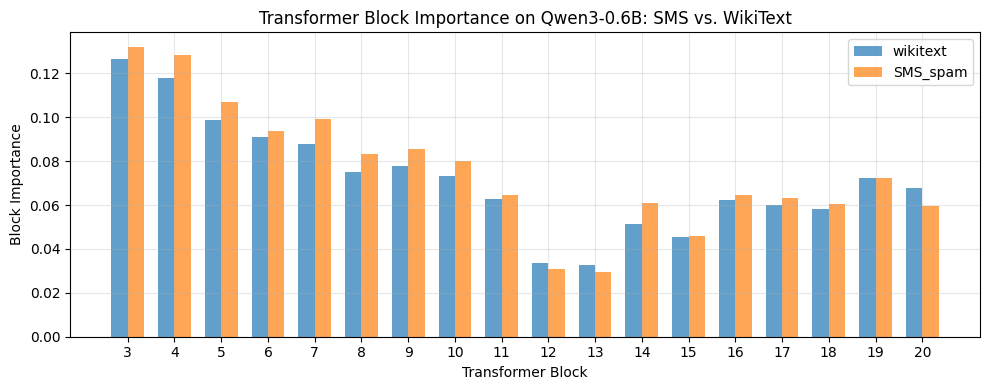

In [32]:
compare_importance(wiki_importance, sms_importance, name1="wikitext", name2="SMS_spam", start=3, end=20)

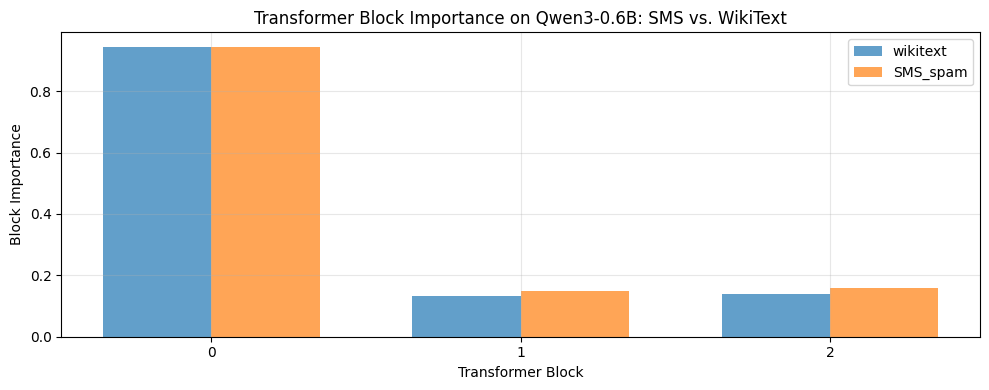

In [33]:
compare_importance(wiki_importance, sms_importance, name1="wikitext", name2="SMS_spam", start=0, end=2)

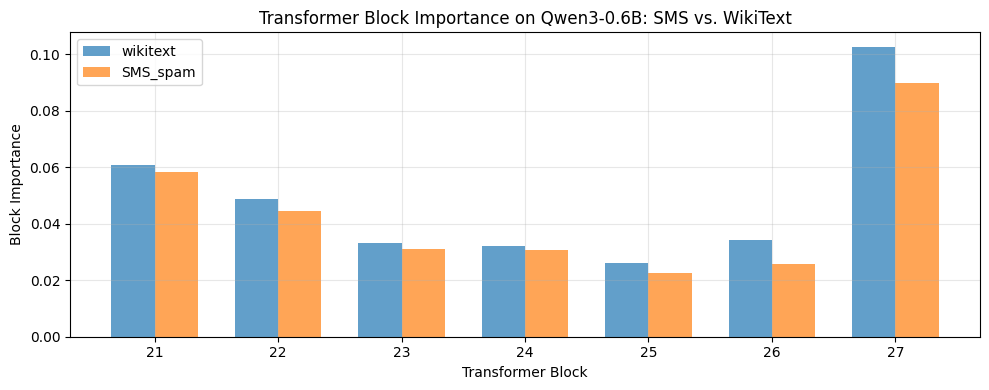

In [34]:
compare_importance(wiki_importance, sms_importance, name1="wikitext", name2="SMS_spam", start=21, end=27)

The results of our comparison reveal a clear pattern. The first layers (0–2) and the last one (27) prove to be important in both datasets, suggesting that they perform fundamental functions, such as the initial processing of the input and the consolidation of the output.

The key difference lies in the behavior of the intermediate layers (roughly 3–26). While in the complex text of Wikitext these layers carry out a measurable job of semantic refinement, in the simple SMS text their contribution is practically null, becoming “passive.” This shows that the importance of a layer varies depending on the complexity of the task, thus validating “depth pruning” as an effective strategy to create more efficient models for specialized tasks.


### Creating models using optipfair.

We'll create a function to select the blocks to delete.

This function can use the protection heuristic, always keeping the first four blocks and the last two. It will also avoid deleting two consecutive blocks.


In [35]:
def select_layers_to_prune(importance_scores,
                           num_layers=2,
                           heuristic_protection=True,
                           adjacent_protection=True):
    """
      Select layers following best practices:
      - Non-consecutive
      - Distributed throughout the model
      - Avoid very early layers (0-2) and the last one (27)
    """
    # Order by importance
    sorted_layers = sorted(importance_scores.items(), key=lambda x: x[1])

    selected = []
    for layer, score in sorted_layers:
        # Skip protected layers
        if heuristic_protection and layer in [0, 1, 2, 3, 27]:
            continue

        # Skip if adjacent
        if adjacent_protection and any(abs(layer - l) == 1 for l in selected):
            continue

        selected.append(layer)

        if len(selected) >= num_layers:
            break

    return selected

In [36]:
wiki_importance = analyze_layer_importance(model,
                                       dataloaderwiki,
                                       show_progress=True)

Processing batches: 100%|██████████| 250/250 [01:00<00:00,  4.16it/s]


In [37]:
wiki_layers_2_remove = select_layers_to_prune(wiki_importance, num_layers=3)
print (wiki_layers_2_remove)

[7, 18, 20]


In [38]:
wiki_model = prune_model(
        model=deepcopy(model),
        pruning_type="DEPTH",
        layer_indices=wiki_layers_2_remove,
        show_progress=True,
    )

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 531405.03it/s]


In [39]:
sms_layers_2_remove = select_layers_to_prune(sms_importance, num_layers=3)
print (sms_layers_2_remove)

[25, 13, 23]


In [40]:
sms_model = prune_model(
        model=deepcopy(model),
        pruning_type="DEPTH",
        layer_indices=sms_layers_2_remove,
        show_progress=True,
    )

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 309053.98it/s]


In [41]:
wiki_model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-24): 25 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layernorm): Qwe

## 4.3.5 Analysis of the benchmarks

### Measuring Loss & Perplexity over SMS_Spam

In [42]:
metrics_base_sms = evaluate_metrics(model, dataloadersms)
metrics_sms_sms = evaluate_metrics(sms_model, dataloadersms)
metrics_wiki_sms = evaluate_metrics(wiki_model, dataloadersms)

Evaluating: 100%|██████████| 250/250 [00:58<00:00,  4.24it/s]


In [43]:
metrics_base_sms

{'loss': 5.617484021639687, 'perplexity': np.float64(275.19612399504877)}

In [44]:
metrics_sms_sms

{'loss': 5.984225436814943, 'perplexity': np.float64(397.11481158115384)}

In [45]:
metrics_wiki_sms

{'loss': 6.098359334765458, 'perplexity': np.float64(445.12686648760405)}

In [46]:
model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layernorm): Qwe

In [47]:
metrics_base_wiki = evaluate_metrics(model, dataloaderwiki)
metrics_wiki_wiki = evaluate_metrics(wiki_model, dataloaderwiki)
metrics_sms_wiki = evaluate_metrics(sms_model, dataloaderwiki)

Evaluating: 100%|██████████| 250/250 [00:57<00:00,  4.32it/s]


In [48]:
metrics_base_wiki

{'loss': 3.7215316249553623, 'perplexity': np.float64(41.32764410967076)}

In [49]:
metrics_wiki_wiki

{'loss': 4.410061876846136, 'perplexity': np.float64(82.27455423663422)}

In [50]:
metrics_sms_wiki

{'loss': 4.261815875239626, 'perplexity': np.float64(70.938682365168)}

### General benchmarks

In [51]:
def model_evaluation(model_obj, tokenizer, tasks, limit=100):
    """
    Runs lm-eval on a PyTorch model object already in memory.

    Args:
        model_obj: The PyTorch model object to evaluate.
        tokenizer: The tokenizer object.
        tasks (list): A list of task names.
        limit (int): The number of samples per task.
    """
    print(f"Starting lm-eval on model '{model_obj.config._name_or_path}' for tasks: {tasks}")

    # Wrap the local model object and tokenizer for lm-eval
    model_wrapper = HFLM(
        pretrained=model_obj,
        tokenizer=tokenizer,
        device=str(device)
    )

    results = evaluator.simple_evaluate(
        model=model_wrapper,
        tasks=tasks,
        num_fewshot=0,
        limit=limit,
        device=str(device),
        #confirm_run_unsafe_code=True
    )

    # Format results for clean display
    formatted_results = {}
    for task_name, res in results["results"].items():
        # Look for accuracy ('acc') first, then perplexity ('ppl')
        if 'acc,none' in res:
            metric_val = res.get('acc,none', 0)
        elif 'ppl,none' in res:
             metric_val = res.get('ppl,none', 0)
        else:
            metric_val = 0 # Fallback

        formatted_results[task_name] = f"{metric_val:.4f}"

    print(json.dumps(formatted_results, indent=2))
    return formatted_results

In [52]:
benchmark_tasks = ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai']

In [53]:
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
base_model_results = model_evaluation(model, tokenizer, benchmark_tasks, limit=100)

Starting lm-eval on model 'Qwen/Qwen3-0.6B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai']


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/5153 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 1099/1099 [00:57<00:00, 19.05it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 425.53it/s]


{
  "arc_easy": "0.5900",
  "hellaswag": "0.4300",
  "lambada_openai": "0.4000",
  "winogrande": "0.6100"
}


In [54]:
base_model_results

{'arc_easy': '0.5900',
 'hellaswag': '0.4300',
 'lambada_openai': '0.4000',
 'winogrande': '0.6100'}

In [55]:
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
sms_model_results = model_evaluation(sms_model, tokenizer, benchmark_tasks, limit=100)

Starting lm-eval on model 'Qwen/Qwen3-0.6B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai']


Running loglikelihood requests: 100%|██████████| 1099/1099 [00:51<00:00, 21.47it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 418.01it/s]


{
  "arc_easy": "0.4700",
  "hellaswag": "0.4200",
  "lambada_openai": "0.2800",
  "winogrande": "0.5600"
}


In [56]:
sms_model_results

{'arc_easy': '0.4700',
 'hellaswag': '0.4200',
 'lambada_openai': '0.2800',
 'winogrande': '0.5600'}

In [57]:
wiki_model_results = model_evaluation(wiki_model, tokenizer, benchmark_tasks, limit=100)

Starting lm-eval on model 'Qwen/Qwen3-0.6B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai']


Running loglikelihood requests: 100%|██████████| 1099/1099 [00:52<00:00, 20.91it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 291.25it/s]


{
  "arc_easy": "0.5000",
  "hellaswag": "0.3800",
  "lambada_openai": "0.2400",
  "winogrande": "0.4900"
}


In [58]:
wiki_model_results

{'arc_easy': '0.5000',
 'hellaswag': '0.3800',
 'lambada_openai': '0.2400',
 'winogrande': '0.4900'}

### Measuring Inference Performance Benchmarks

Now we'll measure the inference performance of the pruned models and compare them with the base model. We'll measure:
- **Inference Time**: Total time to process multiple prompts
- **Time to First Token (TTFT)**: Time from input to first generated token
- **Throughput**: Tokens generated per second

In [59]:
import gc
import time

def clear_gpu_cache():
    """Clear GPU cache completely"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 50) -> str:
    """Generate text with the model"""
    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            num_return_sequences=1,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=3,
            no_repeat_ngram_size=2
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

def measure_inference_time(model, tokenizer, prompts, num_runs=5):
    """Measure average inference time across multiple runs"""
    times = []

    # Warm up GPU
    print("Warming up model...")
    clear_gpu_cache()
    for _ in range(20):
        _ = generate_text(model, tokenizer, "warmup", max_new_tokens=50)
    torch.cuda.synchronize()

    for run in range(num_runs):
        start_time = time.time()

        for prompt in prompts:
            inputs = tokenizer(prompt, return_tensors='pt').to(device)
            with torch.no_grad():
                _ = model.generate(
                    inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    max_new_tokens=50,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id
                )

        end_time = time.time()
        times.append(end_time - start_time)

    return {
        'mean_time': np.mean(times),
        'std_time': np.std(times),
        'all_times': times
    }

In [60]:
from transformers import StoppingCriteria, StoppingCriteriaList
import gc
def clear_gpu_cache():
    """Limpia completamente la cache de GPU"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

# Clase callback para capturar el tiempo del primer token
class FirstTokenTimeLogger(StoppingCriteria):
    def __init__(self, device):
        self.start_time = time.time()
        self.ttft = None
        self.device = device

    def __call__(self, input_ids, scores, **kwargs):
        # Sincroniza para una medición precisa en GPU
        torch.cuda.synchronize(self.device)
        if self.ttft is None:
            # Captura el tiempo en la primera llamada (después del primer token)
            self.ttft = time.time() - self.start_time
        return False # Devuelve False para no detener la generación

def measure_detailed_performance(model, tokenizer, data_source, num_runs=3, max_new_tokens=50, max_samples=None):
    """
    Measure TTFT and throughput.

    Args:
        data_source: List of prompts (strings) OR DataLoader
        max_samples: Limit number of samples (None = all)
    """
    device = model.device

    # Check if data_source is a DataLoader
    is_dataloader = hasattr(data_source, '__iter__') and hasattr(data_source, 'dataset')

    # Extract prompts
    if is_dataloader:
        prompts = []
        for i, batch in enumerate(data_source):
            if max_samples and len(prompts) >= max_samples:
                break
            # Decode batch to text
            input_ids = batch['input_ids']
            for ids in input_ids:
                if max_samples and len(prompts) >= max_samples:
                    break
                ids_no_pad = ids[ids != tokenizer.pad_token_id]
                if len(ids_no_pad) > 0:  # Skip empty sequences
                    prompt = tokenizer.decode(ids_no_pad, skip_special_tokens=True)
                    if prompt.strip():  # Skip empty strings
                        prompts.append(prompt)
    else:
        prompts = data_source

    times = []
    ttfts = []
    throughputs = []

    # Warmup
    print("Warming up model...")
    for _ in range(10):
        inputs = tokenizer("warmup", return_tensors='pt').to(device)
        _ = model.generate(inputs.input_ids, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id)
    torch.cuda.synchronize(device)

    print(f"Starting measurement with {len(prompts)} prompts...")
    for run in range(num_runs):
        run_times = []
        run_ttfts = []
        run_tokens = []

        for prompt in prompts:
            inputs = tokenizer(prompt, return_tensors='pt').to(device)

            # Skip if input is too short
            if inputs['input_ids'].shape[1] < 2:
                continue

            time_logger = FirstTokenTimeLogger(device)

            torch.cuda.synchronize(device)
            gen_start = time.time()

            with torch.no_grad():
                outputs = model.generate(
                    inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    max_new_tokens=max_new_tokens,
                    pad_token_id=tokenizer.pad_token_id,
                    stopping_criteria=StoppingCriteriaList([time_logger]),
                    do_sample=False,
                )

            torch.cuda.synchronize(device)
            gen_end = time.time()

            total_time = gen_end - gen_start
            num_tokens = outputs.shape[1] - inputs['input_ids'].shape[1]

            run_times.append(total_time)
            run_ttfts.append(time_logger.ttft)
            run_tokens.append(num_tokens)

        times.append(np.mean(run_times))
        ttfts.append(np.mean(run_ttfts))
        throughputs.append(np.sum(run_tokens) / np.sum(run_times))

    return {
        'mean_time_per_prompt': np.mean(times),
        'std_time_per_prompt': np.std(times),
        'mean_ttft': np.mean(ttfts),
        'std_ttft': np.std(ttfts),
        'mean_throughput_tokens_sec': np.mean(throughputs),
        'std_throughput_tokens_sec': np.std(throughputs)
    }


In [61]:
# With WikiText dataloader
print("Measuring base model on WikiText...")
base_wiki_timing = measure_detailed_performance(model, tokenizer, dataloaderwiki, max_samples=10)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Measuring base model on WikiText...
Warming up model...
Starting measurement with 10 prompts...


In [62]:
print("\nMeasuring wiki_model on WikiText...")
wiki_timing = measure_detailed_performance(wiki_model, tokenizer, dataloaderwiki, max_samples=10)


Measuring wiki_model on WikiText...
Warming up model...
Starting measurement with 10 prompts...


In [63]:
# Calculate speedup
wiki_speedup = base_wiki_timing['mean_time_per_prompt'] / wiki_timing['mean_time_per_prompt']
print(f"\n📊 Wiki Model Speedup: {wiki_speedup:.2f}x")


📊 Wiki Model Speedup: 1.17x


In [64]:
# With SMS dataloader
print("Measuring base model on SMS...")
base_sms_timing = measure_detailed_performance(model, tokenizer, dataloadersms, max_samples=10)

print("\nMeasuring sms_model on SMS...")
sms_timing = measure_detailed_performance(sms_model, tokenizer, dataloadersms, max_samples=10)

Measuring base model on SMS...
Warming up model...
Starting measurement with 10 prompts...

Measuring sms_model on SMS...
Warming up model...
Starting measurement with 10 prompts...


In [65]:
# Calculate speedup
sms_speedup = base_sms_timing['mean_time_per_prompt'] / sms_timing['mean_time_per_prompt']
print(f"\n📊 SMS Model Speedup: {sms_speedup:.2f}x")


📊 SMS Model Speedup: 1.11x


In [66]:
# Calculate speedups for inference time
wiki_speedup = base_wiki_timing['mean_time_per_prompt'] / wiki_timing['mean_time_per_prompt']
sms_speedup = base_sms_timing['mean_time_per_prompt'] / sms_timing['mean_time_per_prompt']

wiki_time_reduction = (base_wiki_timing['mean_time_per_prompt'] - wiki_timing['mean_time_per_prompt']) / base_wiki_timing['mean_time_per_prompt'] * 100
sms_time_reduction = (base_sms_timing['mean_time_per_prompt'] - sms_timing['mean_time_per_prompt']) / base_sms_timing['mean_time_per_prompt'] * 100

# Calculate speedups for TTFT (lower is better)
wiki_ttft_speedup = base_wiki_timing['mean_ttft'] / wiki_timing['mean_ttft']
sms_ttft_speedup = base_sms_timing['mean_ttft'] / sms_timing['mean_ttft']

wiki_ttft_reduction = (base_wiki_timing['mean_ttft'] - wiki_timing['mean_ttft']) / base_wiki_timing['mean_ttft'] * 100
sms_ttft_reduction = (base_sms_timing['mean_ttft'] - sms_timing['mean_ttft']) / base_sms_timing['mean_ttft'] * 100

# Calculate speedups for Throughput (higher is better)
wiki_throughput_speedup = wiki_timing['mean_throughput_tokens_sec'] / base_wiki_timing['mean_throughput_tokens_sec']
sms_throughput_speedup = sms_timing['mean_throughput_tokens_sec'] / base_sms_timing['mean_throughput_tokens_sec']

wiki_throughput_improvement = (wiki_timing['mean_throughput_tokens_sec'] - base_wiki_timing['mean_throughput_tokens_sec']) / base_wiki_timing['mean_throughput_tokens_sec'] * 100
sms_throughput_improvement = (sms_timing['mean_throughput_tokens_sec'] - base_sms_timing['mean_throughput_tokens_sec']) / base_sms_timing['mean_throughput_tokens_sec'] * 100

print(f"\n📊 Performance Benchmark Results:\n")
print("="*70)
print(f"Base Model Wiki:")
print(f"  Inference Time: {base_wiki_timing['mean_time_per_prompt']:.3f}s ± {base_wiki_timing['std_time_per_prompt']:.3f}s")
print(f"  TTFT: {base_wiki_timing['mean_ttft']*1000:.2f}ms ± {base_wiki_timing['std_ttft']*1000:.2f}ms")
print(f"  Throughput: {base_wiki_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {base_wiki_timing['std_throughput_tokens_sec']:.2f}")
print("="*70)
print(f"Base Model SMS:")
print(f"  Inference Time: {base_sms_timing['mean_time_per_prompt']:.3f}s ± {base_sms_timing['std_time_per_prompt']:.3f}s")
print(f"  TTFT: {base_sms_timing['mean_ttft']*1000:.2f}ms ± {base_sms_timing['std_ttft']*1000:.2f}ms")
print(f"  Throughput: {base_sms_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {base_sms_timing['std_throughput_tokens_sec']:.2f}")
print("="*70)
print(f"Wiki Model (pruned):")
print(f"  Inference Time: {wiki_timing['mean_time_per_prompt']:.3f}s ± {wiki_timing['std_time_per_prompt']:.3f}s")
print(f"    → Speedup: {wiki_speedup:.2f}x ({wiki_time_reduction:+.1f}%)")
print(f"  TTFT: {wiki_timing['mean_ttft']*1000:.2f}ms ± {wiki_timing['std_ttft']*1000:.2f}ms")
print(f"    → Speedup: {wiki_ttft_speedup:.2f}x ({wiki_ttft_reduction:+.1f}%)")
print(f"  Throughput: {wiki_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {wiki_timing['std_throughput_tokens_sec']:.2f}")
print(f"    → Speedup: {wiki_throughput_speedup:.2f}x ({wiki_throughput_improvement:+.1f}%)")
print("="*70)
print(f"SMS Model (pruned):")
print(f"  Inference Time: {sms_timing['mean_time_per_prompt']:.3f}s ± {sms_timing['std_time_per_prompt']:.3f}s")
print(f"    → Speedup: {sms_speedup:.2f}x ({sms_time_reduction:+.1f}%)")
print(f"  TTFT: {sms_timing['mean_ttft']*1000:.2f}ms ± {sms_timing['std_ttft']*1000:.2f}ms")
print(f"    → Speedup: {sms_ttft_speedup:.2f}x ({sms_ttft_reduction:+.1f}%)")
print(f"  Throughput: {sms_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {sms_timing['std_throughput_tokens_sec']:.2f}")
print(f"    → Speedup: {sms_throughput_speedup:.2f}x ({sms_throughput_improvement:+.1f}%)")


📊 Performance Benchmark Results:

Base Model Wiki:
  Inference Time: 2.527s ± 0.024s
  TTFT: 57.60ms ± 1.20ms
  Throughput: 19.79 tokens/s ± 0.19
Base Model SMS:
  Inference Time: 2.374s ± 0.011s
  TTFT: 53.61ms ± 0.35ms
  Throughput: 21.06 tokens/s ± 0.10
Wiki Model (pruned):
  Inference Time: 2.158s ± 0.025s
    → Speedup: 1.17x (+14.6%)
  TTFT: 50.60ms ± 1.25ms
    → Speedup: 1.14x (+12.2%)
  Throughput: 23.17 tokens/s ± 0.26
    → Speedup: 1.17x (+17.1%)
SMS Model (pruned):
  Inference Time: 2.138s ± 0.021s
    → Speedup: 1.11x (+10.0%)
  TTFT: 48.88ms ± 0.61ms
    → Speedup: 1.10x (+8.8%)
  Throughput: 23.39 tokens/s ± 0.23
    → Speedup: 1.11x (+11.1%)


# Summary

In this notebook you have prepared two different models selecting which transformer blocks can be eliminated depending on the data the model is going to use.

First you have measured the importance of the blocks in relation to the dataset and you have eliminated the ones that least modified the data.

The result has been, as you can see in the data above, that each model works better for the dataset that has guided the pruning process.

During the process you have learned you have learned two techniques that are essential:
* The use of PyTorch Hooks.
* Using a metric to measure the work of a transformer block.

